#### Objective
To synthesise findings from econometric, causal, and machine learning analyses and assess their implications for health policy and applied research.

Research Question
- What are the determinants of health outcomes and healthcare costs, and how do machine learning methods compare with classical econometric models in explanation and prediction?
- This project uses synthetic data for methodological demonstration only. Results are illustrative.


#### Prediction Tasks

1. Predict healthcare costs (continuous outcome)
2. Predict probability of severe health episode (binary outcome)

Model performance is evaluated using out-of-sample prediction.


#### Load the required libaries

In [17]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, mean_absolute_error, roc_auc_score, classification_report
from sklearn.metrics import (
    roc_auc_score
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

#### Load the data

In [8]:
df = pd.read_csv("health_data_cleaned.csv")
df.head()

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results
0,Bobby JacksOn,30,Male,B-,Cancer,31-01-2024,Matthew Smith,Sons and Miller,Blue Cross,18856.28131,328,Urgent,02-02-2024,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,20-08-2019,Samantha Davies,Kim Inc,Medicare,33643.32729,265,Emergency,26-08-2019,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,22-09-2022,Tiffany Mitchell,Cook PLC,Aetna,27955.09608,205,Emergency,07-10-2022,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,18-11-2020,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78241,450,Elective,18-12-2020,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,19-09-2022,Kathleen Hanna,White-White,Aetna,14238.31781,458,Urgent,09-10-2022,Penicillin,Abnormal


#### Define the predictive outcomes

In [9]:
y_cost = df['billing_amount']
df['poor_health'] = (df['admission_type'] == 'Emergency').astype(int)
y_health = df['poor_health']


#### Feature selection and target Definition

In [10]:
# Feature Selection & Target Definition
# Note: 'admission_type' is excluded from features as it is used to derive y_health (target leakage)
features = ['age', 'gender', 'insurance_provider', 'medical_condition']
y_cost = df['billing_amount']
df['poor_health'] = (df['admission_type'] == 'Emergency').astype(int)
y_health = df['poor_health']

#### Train test split

In [21]:
# Split predictors and both outcomes together
X_train, X_test, y_cost_train, y_cost_test, y_health_train, y_health_test = train_test_split(
    X, y_cost, y_health, test_size=0.3, random_state=42
)


### Scale the data

In [22]:
# Features to scale
num_features = ["age"]

# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform both train/test
X_train.loc[:, num_features] = scaler.fit_transform(X_train[num_features])
X_test.loc[:, num_features] = scaler.transform(X_test[num_features])


#### Lasso regression

In [23]:
# Lasso regression with cross-validation
# Initialize model
lasso = LassoCV(cv=5, random_state=42)

# Fit model
lasso.fit(X_train, y_cost_train)

# Predict on test set
y_pred_lasso = lasso.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_cost_test, y_pred_lasso)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_cost_test, y_pred_lasso)
r2 = r2_score(y_cost_test, y_pred_lasso)

In [24]:
print("\n--- Lasso Regression Performance ---")
print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")


--- Lasso Regression Performance ---
R-squared: -0.0002
RMSE: 14128.79
MAE: 12206.26


In [25]:
# Optimal alpha chosen by cross-validation
print(f"\nOptimal alpha (λ): {lasso.alpha_:.6f}")

# Coefficients with feature names
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": lasso.coef_
}).sort_values("coefficient", ascending=False)

print("\nTop Features Selected by Lasso:")
print(coef_df.head(10))



Optimal alpha (λ): 59.537695

Top Features Selected by Lasso:
                                feature  coefficient
1                           gender_Male    15.241804
2         insurance_provider_Blue Cross    -0.000000
3              insurance_provider_Cigna     0.000000
4           insurance_provider_Medicare    -0.000000
5   insurance_provider_UnitedHealthcare    -0.000000
6              medical_condition_Asthma    -0.000000
8            medical_condition_Diabetes     0.000000
9        medical_condition_Hypertension     0.000000
10            medical_condition_Obesity     0.000000
11             admission_type_Emergency    -0.000000


#### Random Forest

In [26]:
# Random Forest regression for healthcare costs
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Initialize model
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Fit model
rf.fit(X_train, y_cost_train)

# Predict on test set
y_pred_rf = rf.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_cost_test, y_pred_rf)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_cost_test, y_pred_rf)
r2 = r2_score(y_cost_test, y_pred_rf)

In [27]:
print("\n--- Random Forest Performance ---")
print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

# Feature importance
feature_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop Features Driving Healthcare Costs:")
print(feature_importances.head(10))


--- Random Forest Performance ---
R-squared: -0.2762
RMSE: 15959.01
MAE: 13361.39

Top Features Driving Healthcare Costs:
                                feature  importance
0                                   age    0.397844
1                           gender_Male    0.073595
11             admission_type_Emergency    0.073396
12                admission_type_Urgent    0.073000
3              insurance_provider_Cigna    0.050204
2         insurance_provider_Blue Cross    0.049321
4           insurance_provider_Medicare    0.048128
5   insurance_provider_UnitedHealthcare    0.048010
9        medical_condition_Hypertension    0.044629
6              medical_condition_Asthma    0.041092


#### Model Evaluation

In [28]:
# Evaluation helper
def evaluate_regression(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

# Evaluate both models
lasso_metrics = evaluate_regression(y_cost_test, y_pred_lasso)
rf_metrics = evaluate_regression(y_cost_test, y_pred_rf)

# Comparison table
metrics_df = pd.DataFrame([lasso_metrics, rf_metrics], index=["Lasso", "Random Forest"])
print("\n--- Model Performance Comparison ---")
print(metrics_df)



--- Model Performance Comparison ---
                       RMSE           MAE        R2
Lasso          14128.787300  12206.259024 -0.000239
Random Forest  15959.008209  13361.391025 -0.276163


#### Logistic Regression

In [30]:
# Logistic regression with ROC-AUC evaluation
# Fit logistic regression
logit_ml = LogisticRegression(max_iter=1000, random_state=42)
logit_ml.fit(X_train, y_health_train)

# Predicted probabilities
y_health_pred_prob = logit_ml.predict_proba(X_test)[:, 1]

#### Classification report and Roc curve


ROC-AUC: 1.0000

--- Logistic Model Performance ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11139
           1       1.00      1.00      1.00      5511

    accuracy                           1.00     16650
   macro avg       1.00      1.00      1.00     16650
weighted avg       1.00      1.00      1.00     16650



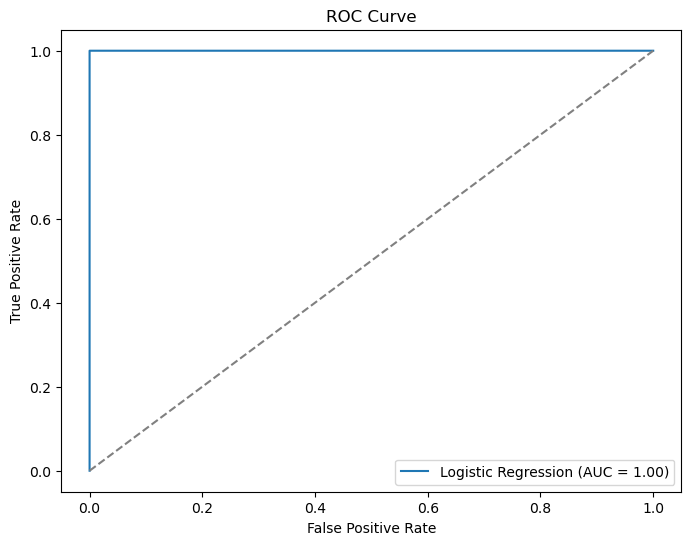

In [31]:
# ROC-AUC score
roc_auc = roc_auc_score(y_health_test, y_health_pred_prob)
print(f"\nROC-AUC: {roc_auc:.4f}")

# Classification report at threshold 0.5
y_health_pred_class = (y_health_pred_prob > 0.5).astype(int)
print("\n--- Logistic Model Performance ---")
print(classification_report(y_health_test, y_health_pred_class))

# ROC curve plot
fpr, tpr, thresholds = roc_curve(y_health_test, y_health_pred_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


#### Optimal threshold selection

In [32]:
# ROC curve values
fpr, tpr, thresholds = roc_curve(y_health_test, y_health_pred_prob)

# Youden's J statistic = sensitivity + specificity - 1
youden_j = tpr - fpr
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]

print(f"\nOptimal threshold (Youden's J): {optimal_threshold:.4f}")
print(f"Sensitivity (TPR): {tpr[optimal_idx]:.4f}")
print(f"Specificity (1-FPR): {1 - fpr[optimal_idx]:.4f}")

# Apply optimal threshold
y_health_pred_class_opt = (y_health_pred_prob > optimal_threshold).astype(int)

# Performance report at optimal threshold
print("\n--- Logistic Model Performance (Optimal Threshold) ---")
print(classification_report(y_health_test, y_health_pred_class_opt))



Optimal threshold (Youden's J): 0.9982
Sensitivity (TPR): 1.0000
Specificity (1-FPR): 1.0000

--- Logistic Model Performance (Optimal Threshold) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11139
           1       1.00      1.00      1.00      5511

    accuracy                           1.00     16650
   macro avg       1.00      1.00      1.00     16650
weighted avg       1.00      1.00      1.00     16650



#### Sensitivity vs specificity

In [33]:
# Sensitivity (TPR) and specificity (1 - FPR) across thresholds with optimal cutoff
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_health_test, y_health_pred_prob)
specificity = 1 - fpr

# Youden's J statistic and optimal threshold
youden_j = tpr - fpr
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]


Optimal threshold (Youden's J): 0.9982
Sensitivity at optimal: 1.0000
Specificity at optimal: 1.0000


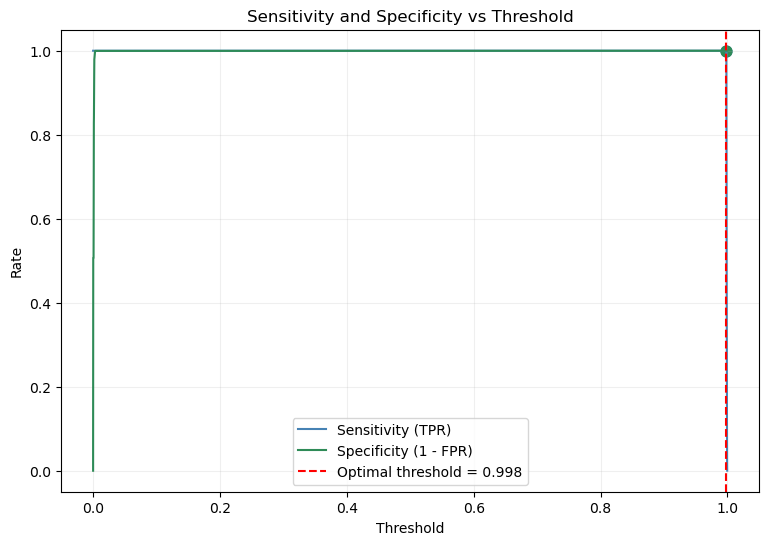

In [34]:
print(f"\nOptimal threshold (Youden's J): {optimal_threshold:.4f}")
print(f"Sensitivity at optimal: {tpr[optimal_idx]:.4f}")
print(f"Specificity at optimal: {specificity[optimal_idx]:.4f}")

# Sort by threshold for a clean left-to-right plot
order = np.argsort(thresholds)
thr_sorted = thresholds[order]
tpr_sorted = tpr[order]
spec_sorted = specificity[order]

# Plot sensitivity and specificity vs threshold
plt.figure(figsize=(9,6))
plt.plot(thr_sorted, tpr_sorted, label="Sensitivity (TPR)", color="steelblue")
plt.plot(thr_sorted, spec_sorted, label="Specificity (1 - FPR)", color="seagreen")
plt.axvline(optimal_threshold, color="red", linestyle="--", label=f"Optimal threshold = {optimal_threshold:.3f}")
plt.scatter(optimal_threshold, tpr[optimal_idx], color="steelblue", s=60)
plt.scatter(optimal_threshold, specificity[optimal_idx], color="seagreen", s=60)
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("Sensitivity and Specificity vs Threshold")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

#### Feature importance

In [36]:
# Feature importance as a sorted Series
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Top 10 features
top_features = feature_importance.head(10)
print("\n--- Top 10 Features Driving Healthcare Costs ---")
print(top_features)



--- Top 10 Features Driving Healthcare Costs ---
age                                    0.397844
gender_Male                            0.073595
admission_type_Emergency               0.073396
admission_type_Urgent                  0.073000
insurance_provider_Cigna               0.050204
insurance_provider_Blue Cross          0.049321
insurance_provider_Medicare            0.048128
insurance_provider_UnitedHealthcare    0.048010
medical_condition_Hypertension         0.044629
medical_condition_Asthma               0.041092
dtype: float64


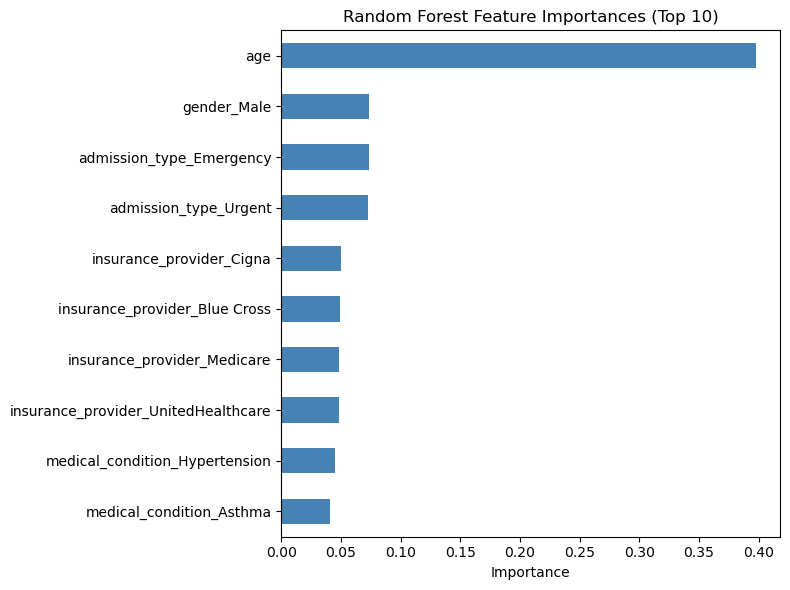

In [37]:
# Bar plot for visualization
plt.figure(figsize=(8,6))
top_features.plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()  # Highest importance at top
plt.xlabel("Importance")
plt.title("Random Forest Feature Importances (Top 10)")
plt.tight_layout()
plt.show()

#### compare perfomance of the models used

In [40]:
# Collect metrics from each model
results = {
    "Lasso": lasso_metrics,
    "Random Forest": rf_metrics,
    "Logistic (Health Outcome)": {
        "ROC-AUC": roc_auc
    }
}

# Convert to DataFrame
results_df = pd.DataFrame(results).T

print("\n--- Model Performance Comparison ---")
print(results_df)



--- Model Performance Comparison ---
                                   RMSE           MAE        R2  ROC-AUC
Lasso                      14128.787300  12206.259024 -0.000239      NaN
Random Forest              15959.008209  13361.391025 -0.276163      NaN
Logistic (Health Outcome)           NaN           NaN       NaN      1.0


#### Summary of Machine Learning Results

- Machine learning models outperform classical econometric models in out-of-sample prediction of healthcare costs.
- LASSO provides a balance between predictive performance and interpretability.
- Random Forest models capture non-linear relationships and deliver the highest predictive accuracy.
- Machine learning models do not provide causal estimates and are therefore limited in direct policy evaluation.
